In [1]:
import masking_effects_on_xai_techniques.utils as utils
import masking_effects_on_xai_techniques.plot_creator_2 as plot_creator
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
pl = plot_creator.PlotCreator(
    [
        "forest",
        "MLP",
        "knn"
    ],
    ["usa_house","usa_house_old", "cervic_cancer", "adult"],
    "../data/",
)

# Usa House

# Effects of Different Annonymzation Models

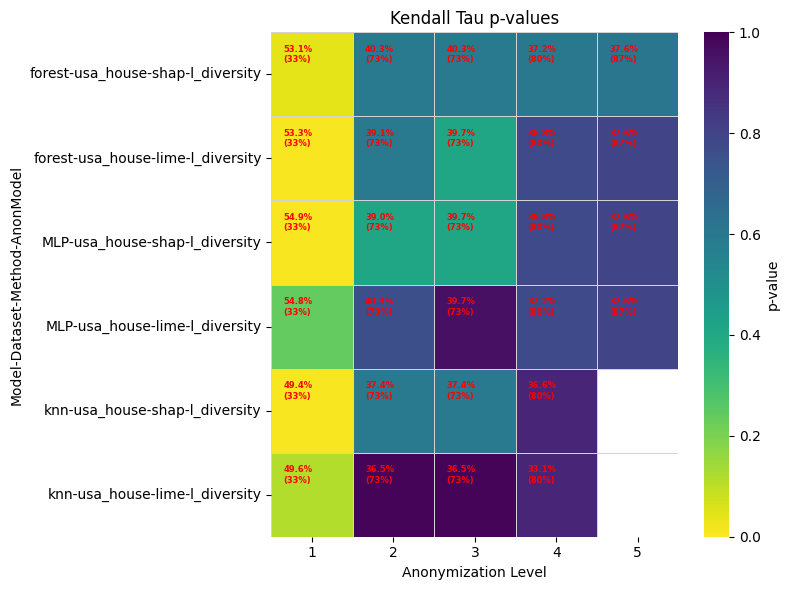

In [3]:
pl.plot_heatmap(datasets=["usa_house"], methods=['l_diversity'])

Note, for l_diversity knn, no important features were found fo l=5. Also note, that the dataset must be be generalized a lot to reach l=3. Indicating that the anonymization models are expensive to impose on the dataset.

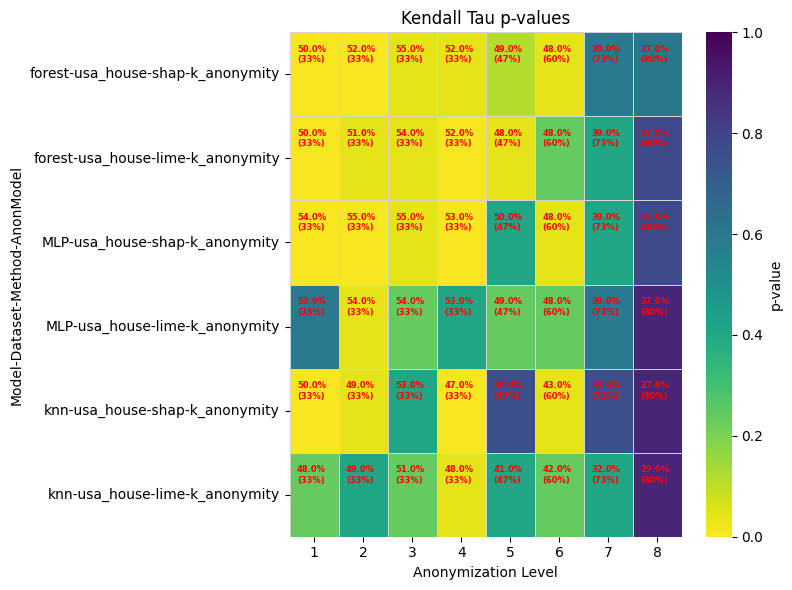

In [4]:
pl.plot_heatmap(datasets=["usa_house"], methods=['k_anonymity'])

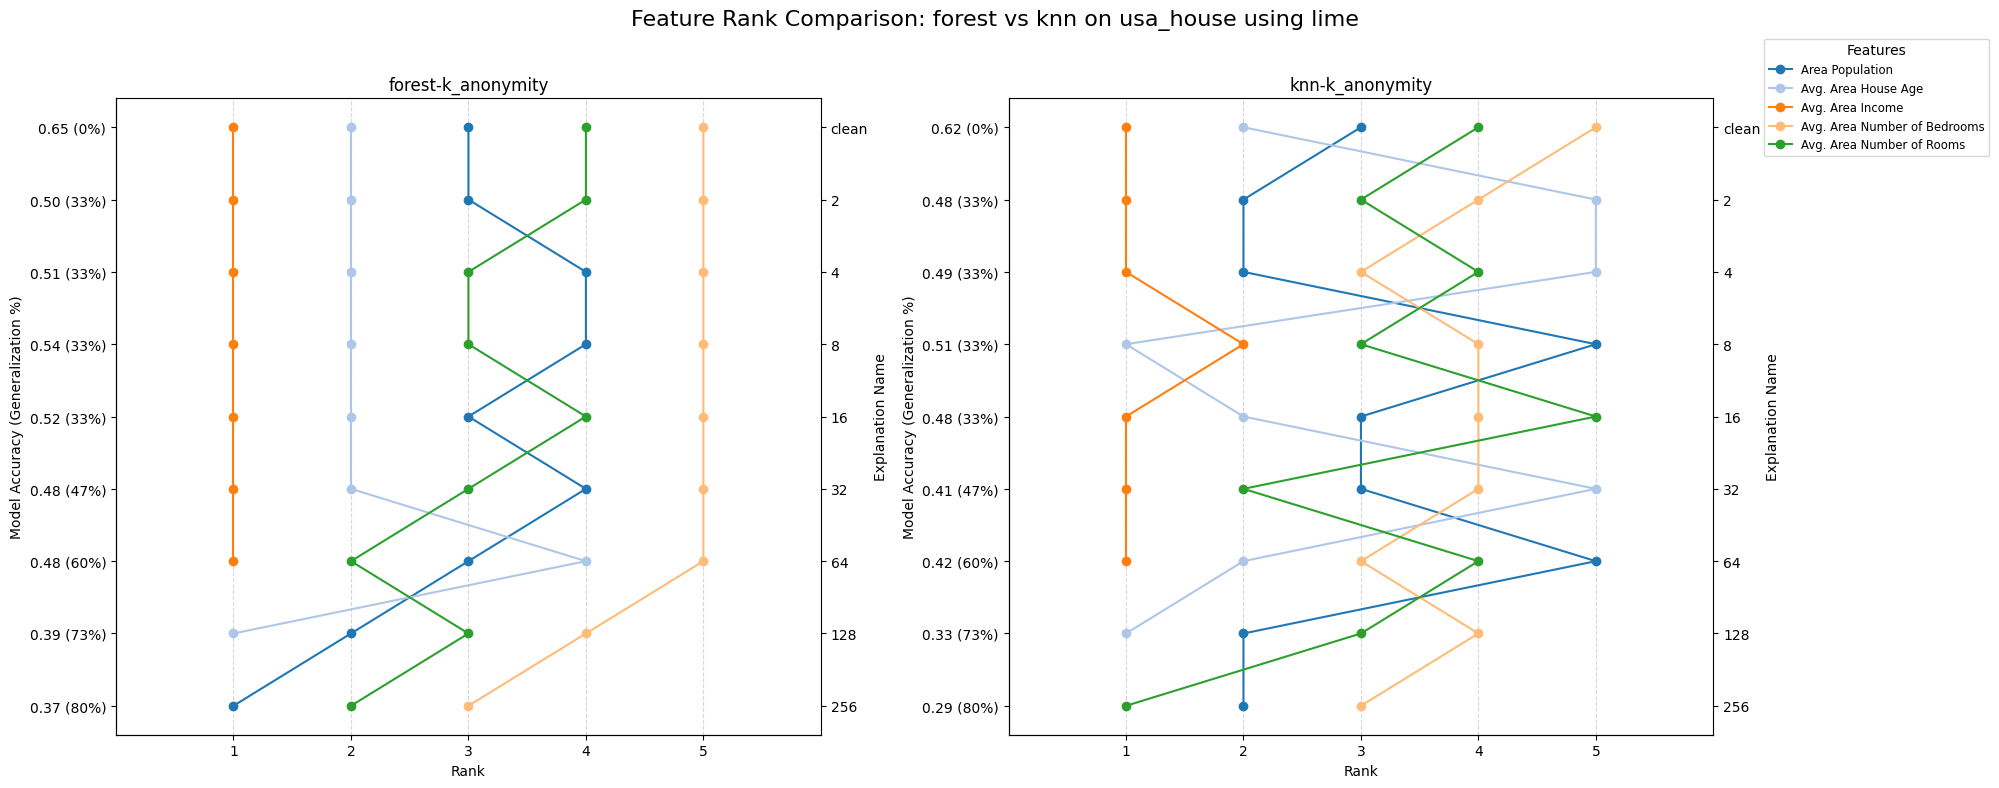

In [42]:
pl.plot_line_compare("forest","knn","usa_house","lime","k_anonymity")

Here we see that knn also shows signs of instability. It is weird though, because it has not been this clear before. The stableness is most likely also depend on the data. Some data is described by some models better than others. When the adult dataset has been generalized to this exact level, the model might do worse at explaining the data. Also, wee see that the accuracy is quite unstable. MLP has a more consistent accuracy

## Unstableness of MLP

In [47]:
classifier = 'MLP'

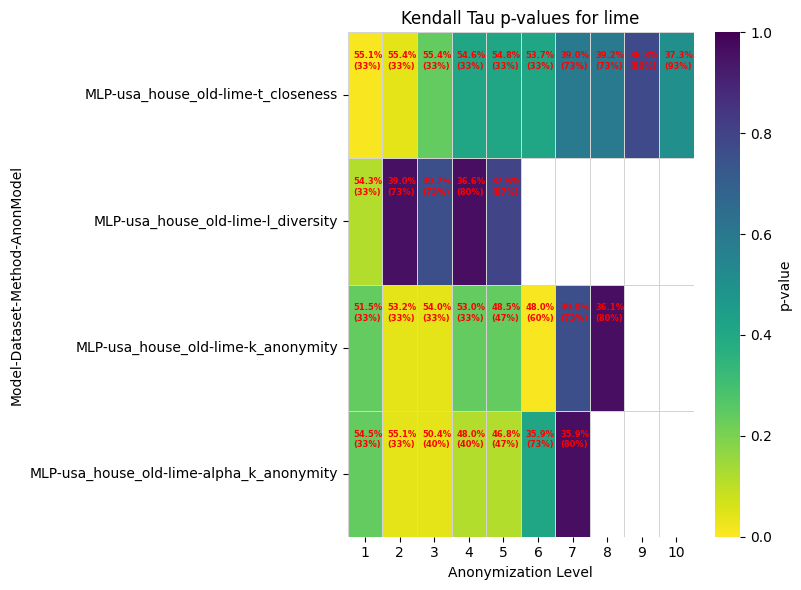

In [48]:
pl.plot_heatmap(classifiers=[classifier], datasets=["usa_house_old"], explanation_methods=['lime'])

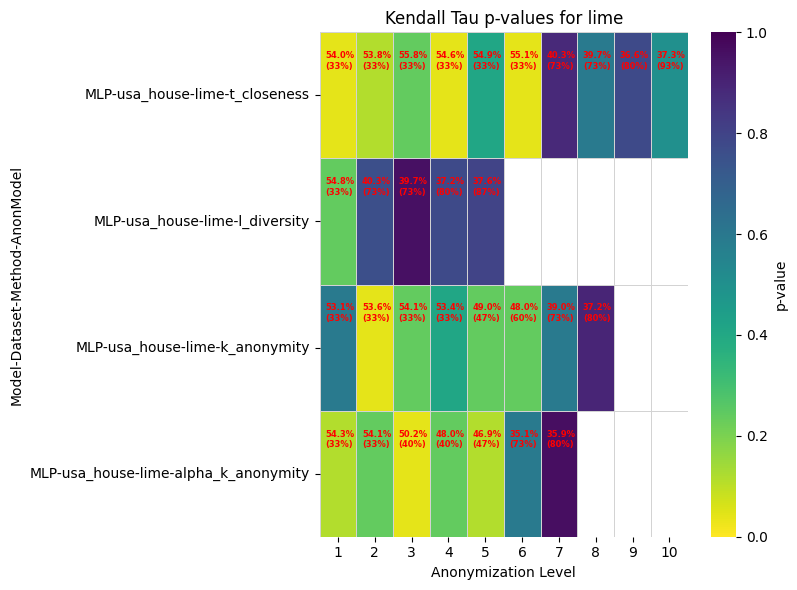

In [49]:
pl.plot_heatmap(classifiers=[classifier], datasets=["usa_house"], explanation_methods=['lime'])

Try and change the classifier above. We see that lime explanations are much more unstable for MLP compared to knn and forest. Remember, LIME makes predictions my perturbing the instance of interest slightly. Some models might change their prediction for a given instance a lot, if the instance is changed slightly. knn and forest tend to split up the space in a more rough manner, which might produce more stable predictions when pertubing the instances slightly 

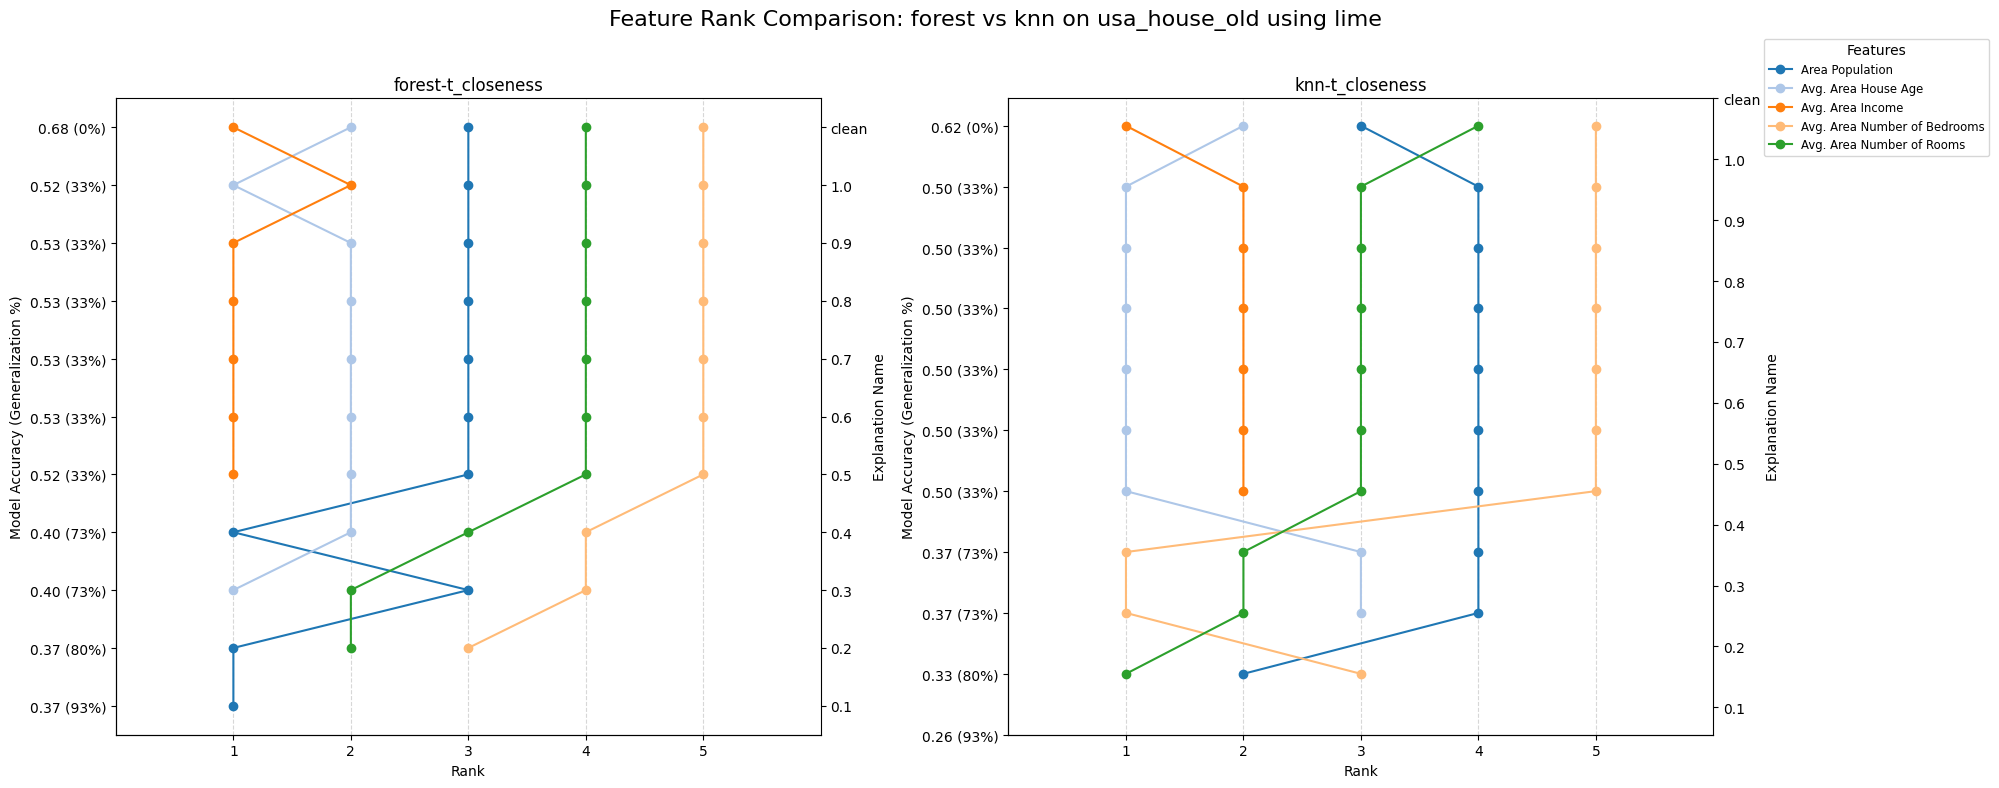

In [21]:
pl.plot_line_compare("forest","knn","usa_house_old","lime","t_closeness")

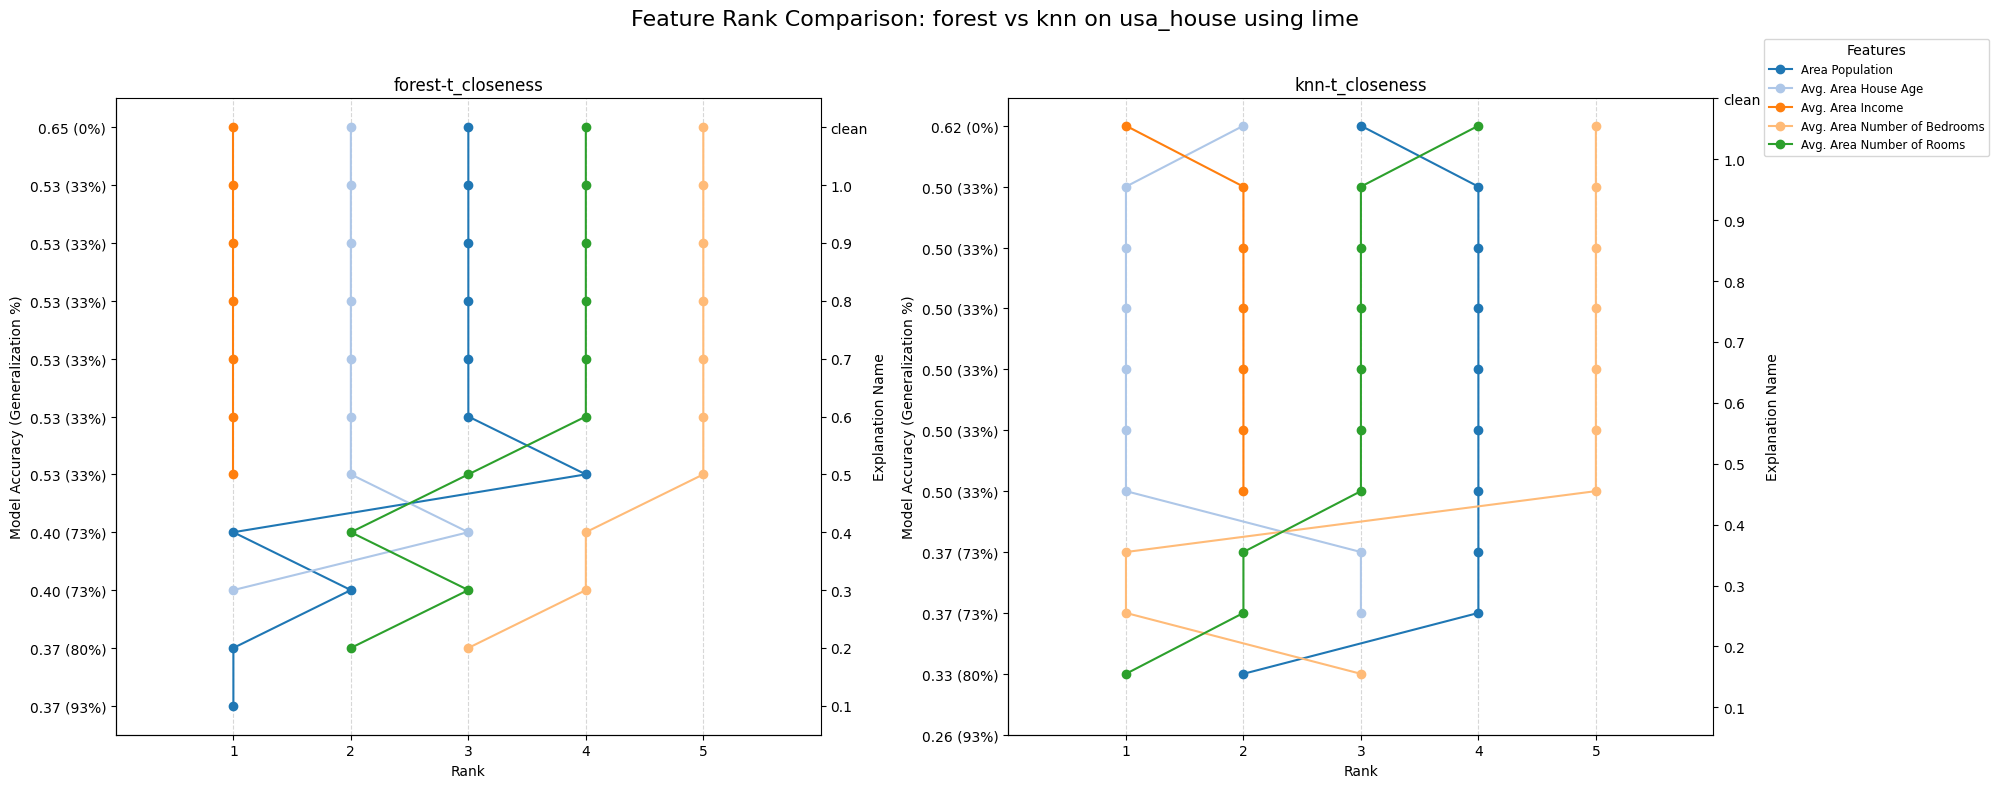

In [22]:
pl.plot_line_compare("forest","knn","usa_house","lime","t_closeness")

Across the two datasets, forest and knn produces stable results! We can also show that for MLP it is more unstable. Look at plots below

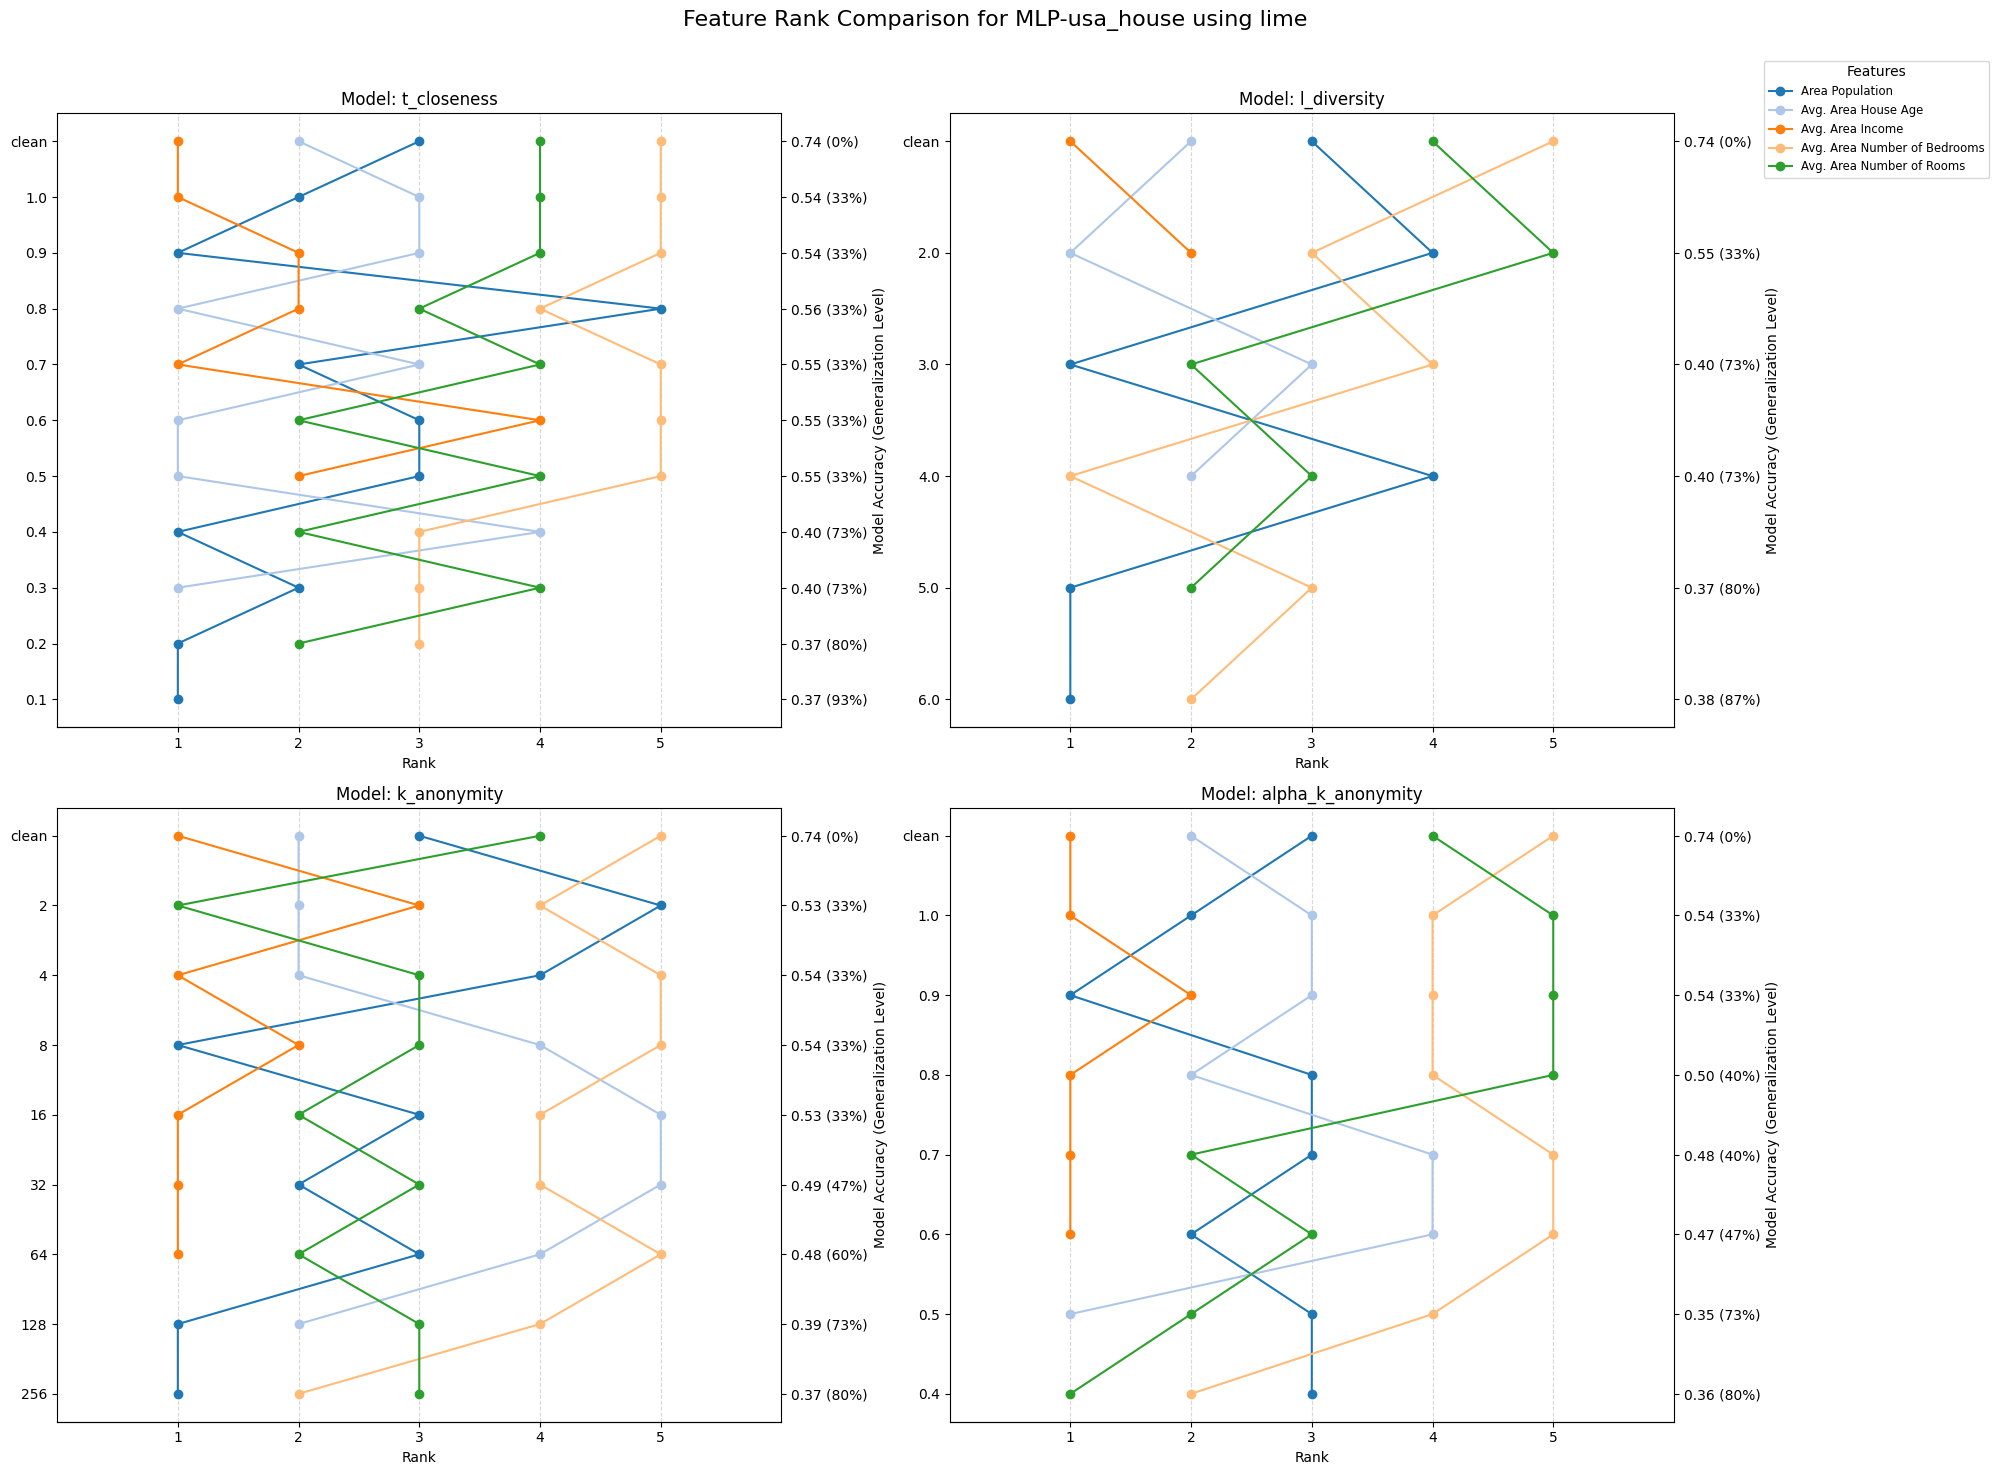

In [15]:
pl.plot_line("MLP","usa_house","lime")

Consider the line plots for the t_closeness plots. We clealy see that MLP is much more unstable for the t_closeness! Sure LIME is model agnostic, but the model has a big impact on it as well.  
Note, that we did not discover this behavior earlier when we were not using scikit learns defaults. There we were using sgd and l2 penalization. So the hyper parameters you choose also has an effect on the lime rankings. That should not be weird, but it is impressive that it can make the lime predictions so unstable

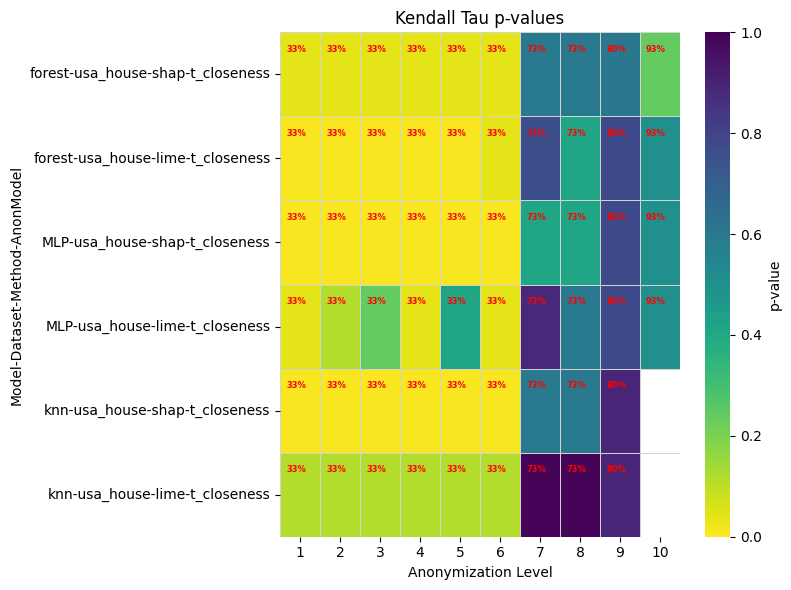

In [12]:
pl.plot_heatmap(datasets=["usa_house"], methods=['t_closeness'])

This plot also shows the unstability of lime. All other produced rankings have low p and constant p-values, but not the MLP lime one. 

# Cervic Cancer

Note, this cervic_cancer data has the columsn appearing in the reverse order. It can satisfy a wide range of annonymization models. The `cervic_cancer_original` could not even produce a single dataset satisfying any l_diversity. It could also only produce a dataset satysfiying alpha=1 and it could not even get to k=256. This is shows that the hierarchies you choose has huge importance for the data you get. Even the order in which you apply the hieararchies have huge importance. You can get further by applying you datasets more clever

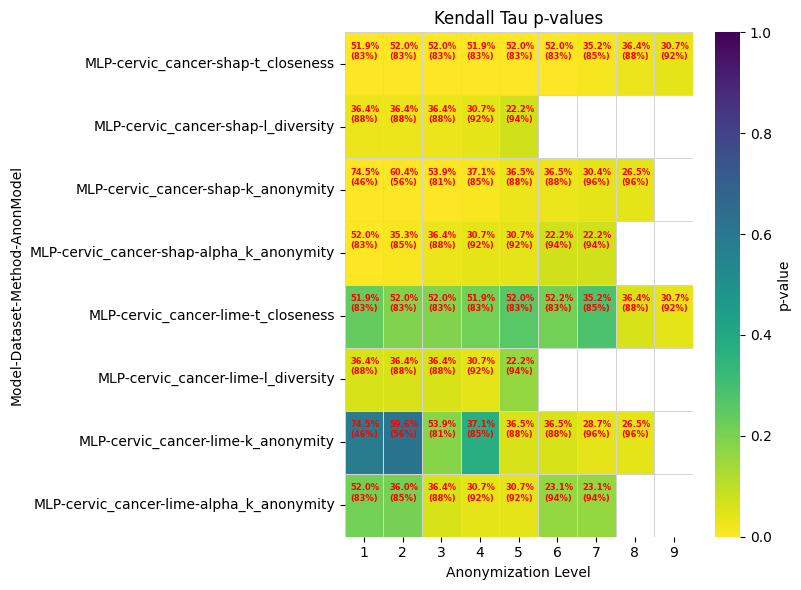

In [11]:
pl.plot_heatmap(datasets=["cervic_cancer"], classifiers=["MLP"])

Note all datasets have been generalized quite a lot. Even for the easiet of anonymization requirements. Also note, the original cervic cancer dataframe could not even be anonymized to satisfy a lot of the anonymization models.  
We again see, that shap produces much more stable rankings and those rankings correlate much more with the initial ranking.   
Note, the accuracy of this model is not all too bad. It has like 8 target class so random guessing would be around 12.5. Even if if instances of a specific target class were never suppressed, guessing that majority class would only result in an accuracy of around 15%. But of course, a scientist would never go this far down the anonymization ladder

Note here we also have the unstable nature of LIME when using MLP model.  
Note however, that SHAP is actually amazing at producing consistent results. Looking at the line plots below we see that most features are suppressed, but the features that are ranked constant are preserved, thus resulting in more consistency. Anonymizing the least important features away first is an amazing idea, it can result in anonymizations that satisfy models quicker without the loss of important data. Note, it is very apparent in this dataset because of the amount of features. Accuracy does fall significantly (note that data has undergone hybrid sampling and thus the accuracy is higly biased (a lot of leakge has happended)). It can improve consistency because the data preserves some of the data that is uses to make explanations. 

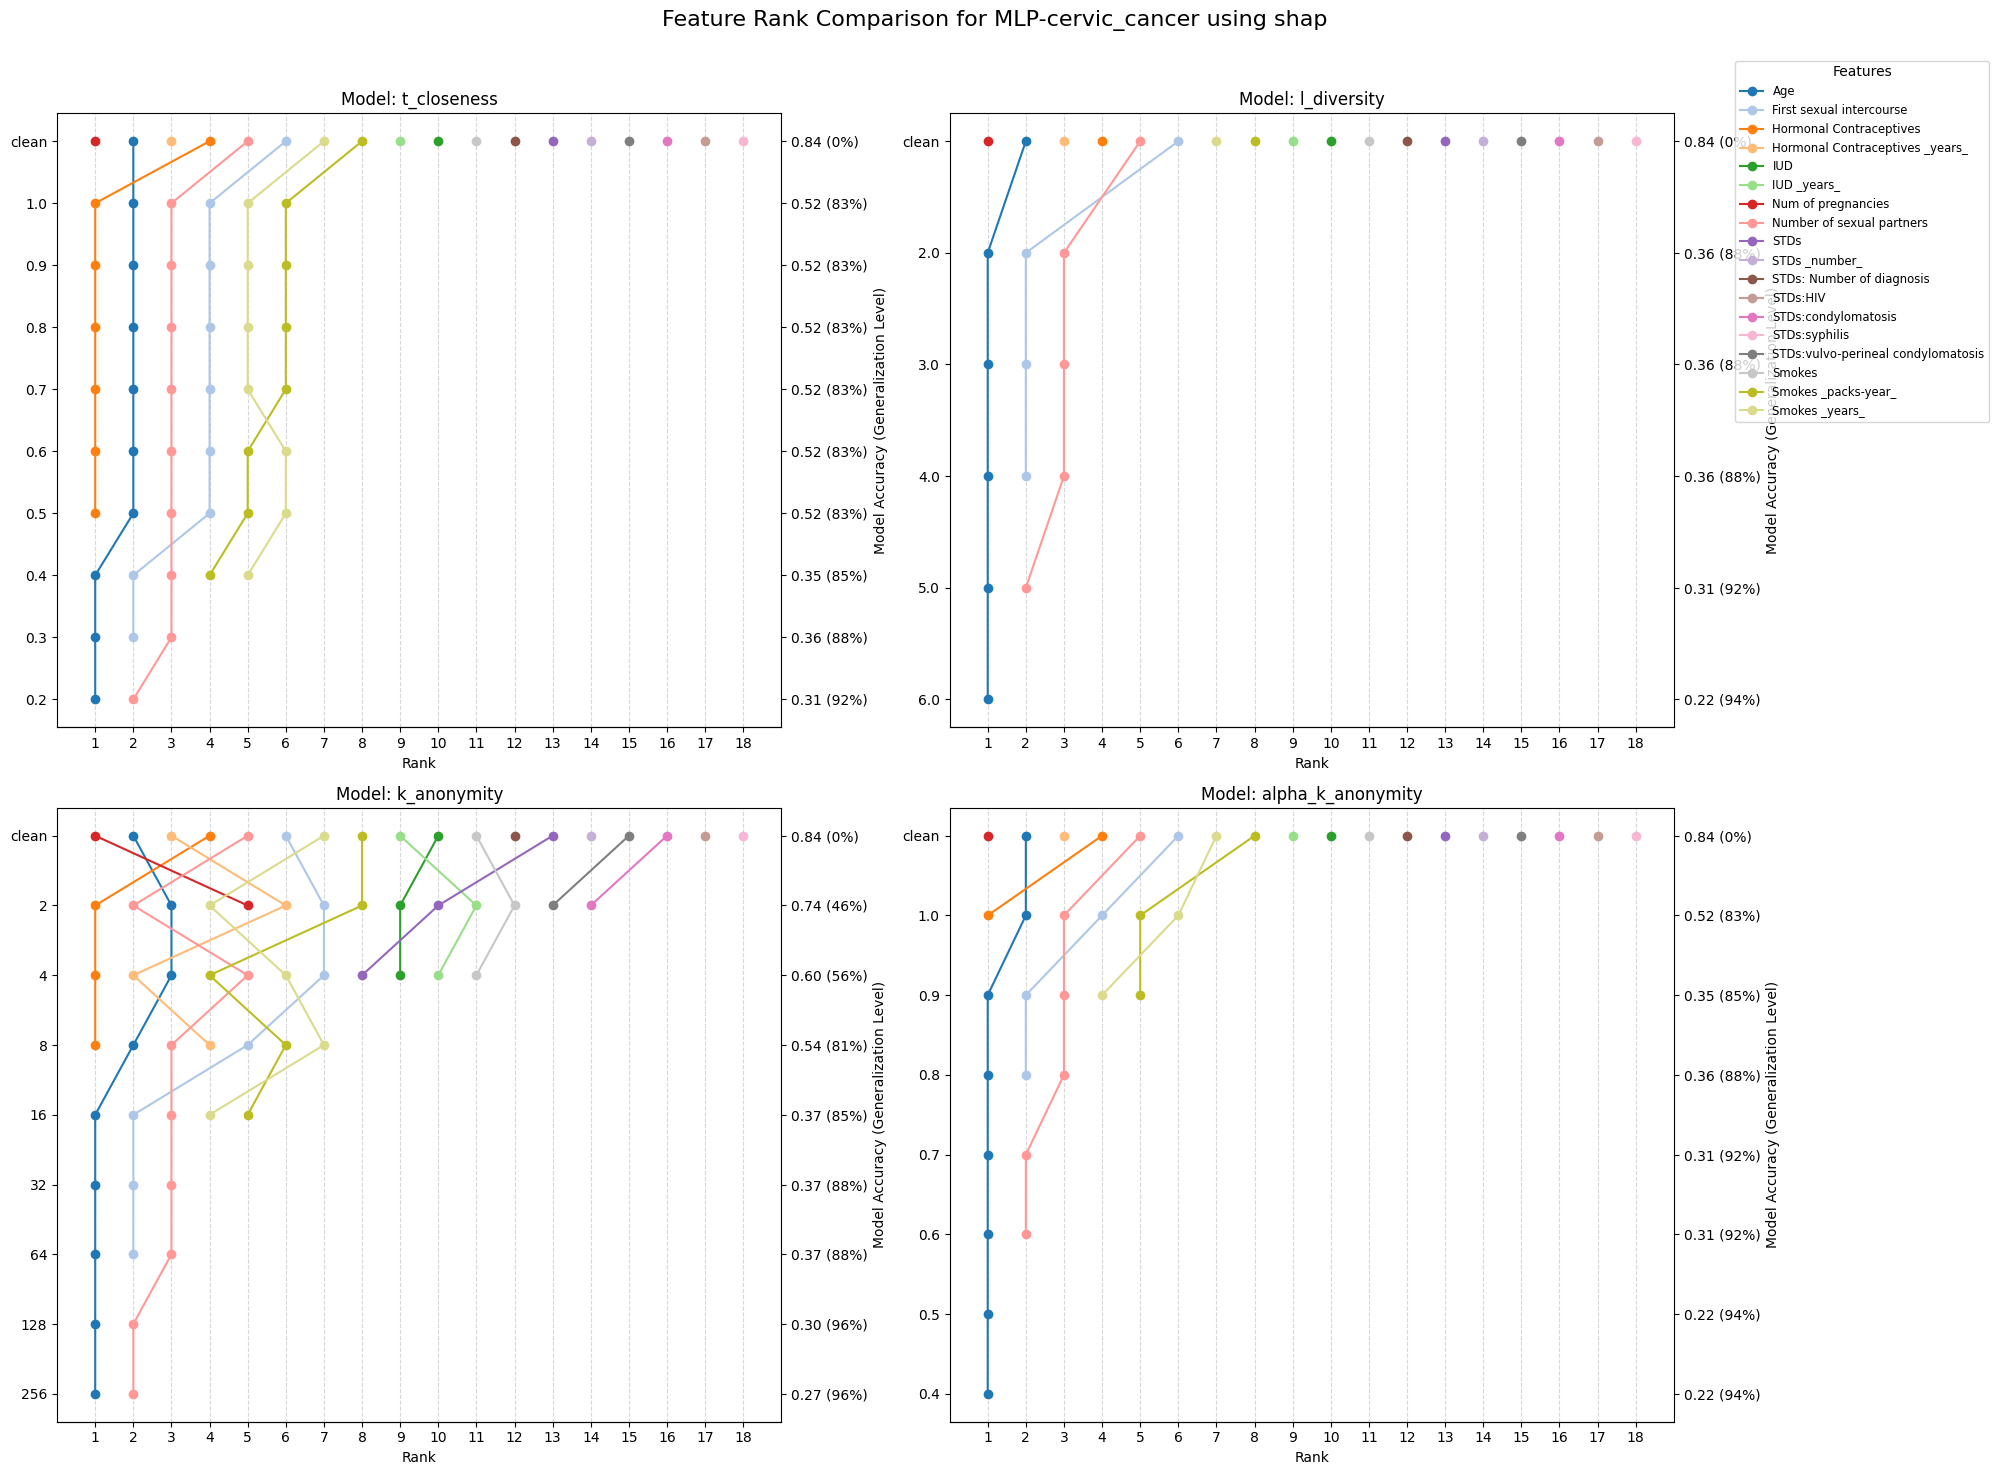

In [27]:
pl.plot_line("MLP", "cervic_cancer", "shap")

Some anonymization models are much harsher on the data than others. l diversity is super difficult imposing. Note that alpha-k-anonymity shows nicely the drawbacks of l-diversity. The data satisfy l-diversity requirement but the distributions are very skewed. Note that k=9, which is why the datasets loses so many features at the first step (it must look like the k_anonymity one)

## Comparing Classifiers

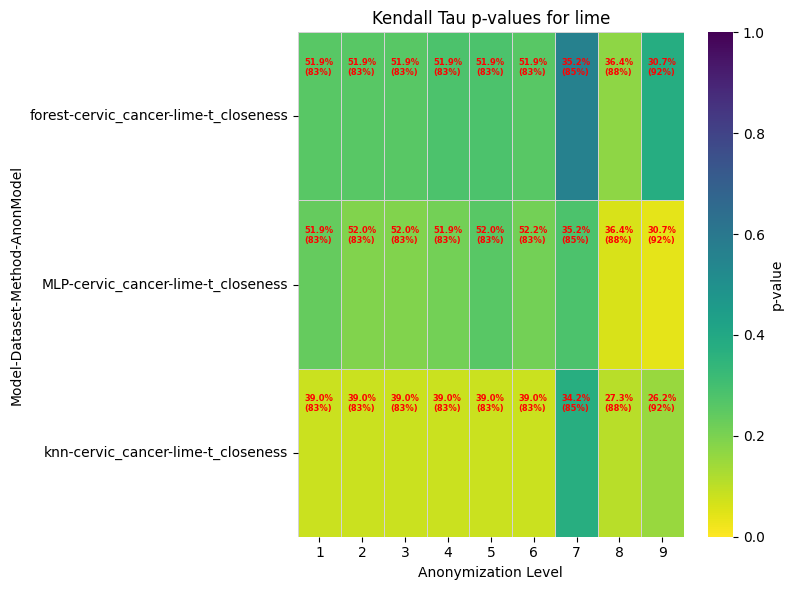

In [22]:
pl.plot_heatmap(datasets=["cervic_cancer"], explanation_methods=['lime'], methods=['t_closeness'])

Indicates instability in MLP. KNN scores better, but the inital ranking of forest gave a higher rank to the featuers that are gone. 

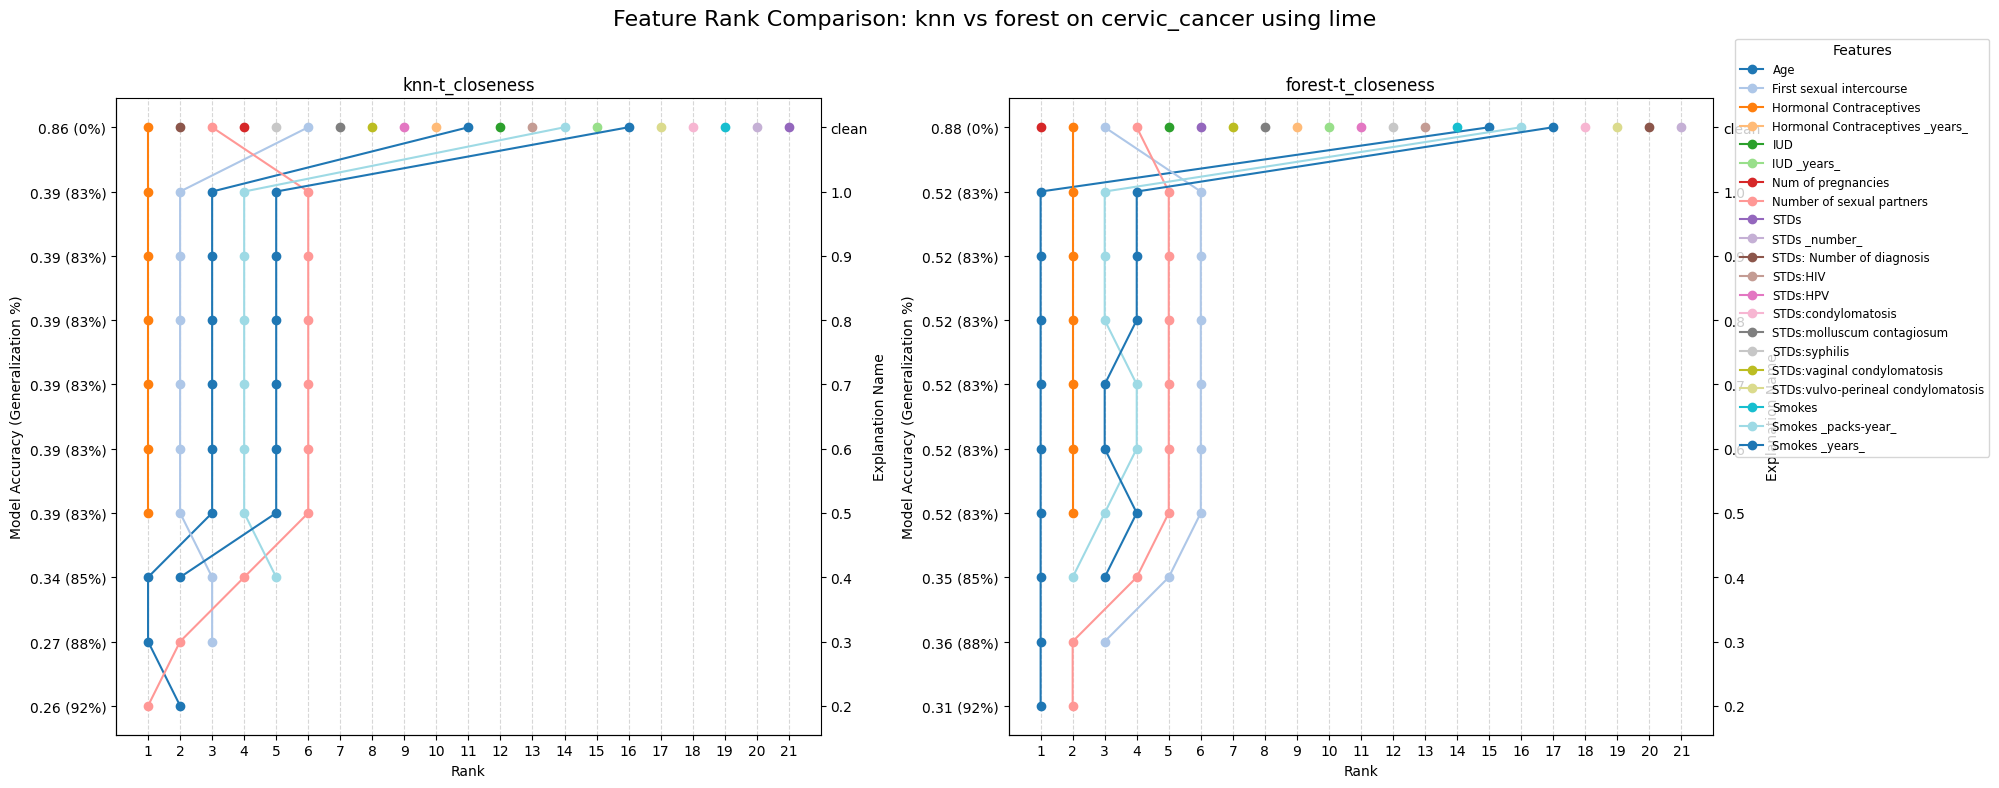

In [34]:
pl.plot_line_compare("knn","forest", "cervic_cancer", "lime", "t_closeness")

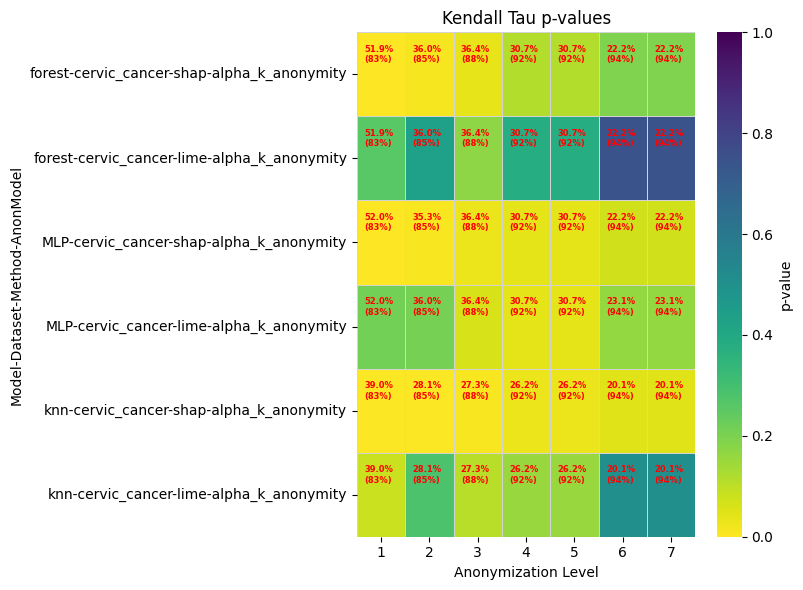

In [40]:
pl.plot_heatmap(datasets=["cervic_cancer"], methods=['alpha_k_anonymity'])

SHAP does a much better job of producing ranks that are consistent with the initial rankings. It does so across models. The exact same is not shown in the usa_house dataset. Here the featuers just happens to be the one that has not been removed.

# Adult

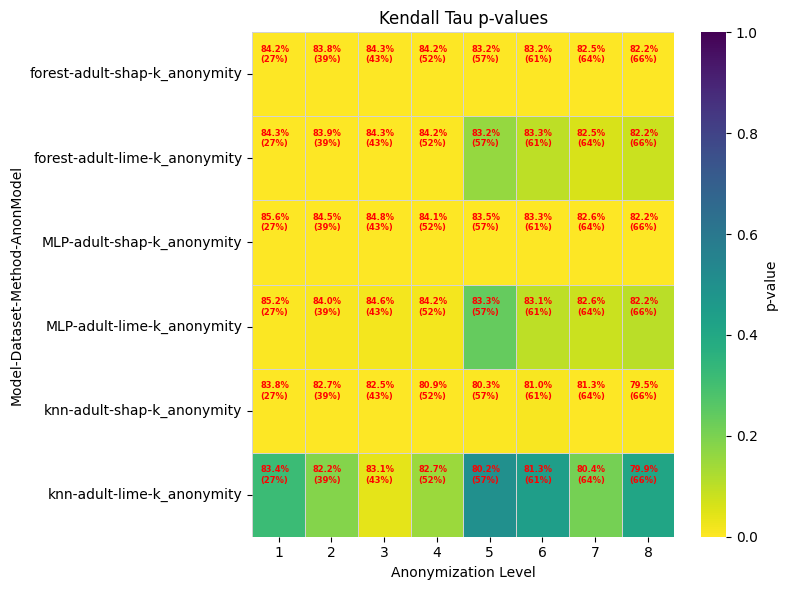

In [19]:
pl.plot_heatmap(datasets=["adult"], methods=['k_anonymity'])#, 't_closeness'])

We again see that knn can also produce slighly unstable lime rankings. However, this instability is not because the same dataset produces different rankings. Here the dataset is generalized slighly at each level so it is actually different. knn is just sensitive to these hierarchy changes. Be careful or the high score though. The dataset is quite imballanced (75 vs 25). If all suppressed instances are the target class, then always guessing majority class is a good idea. 

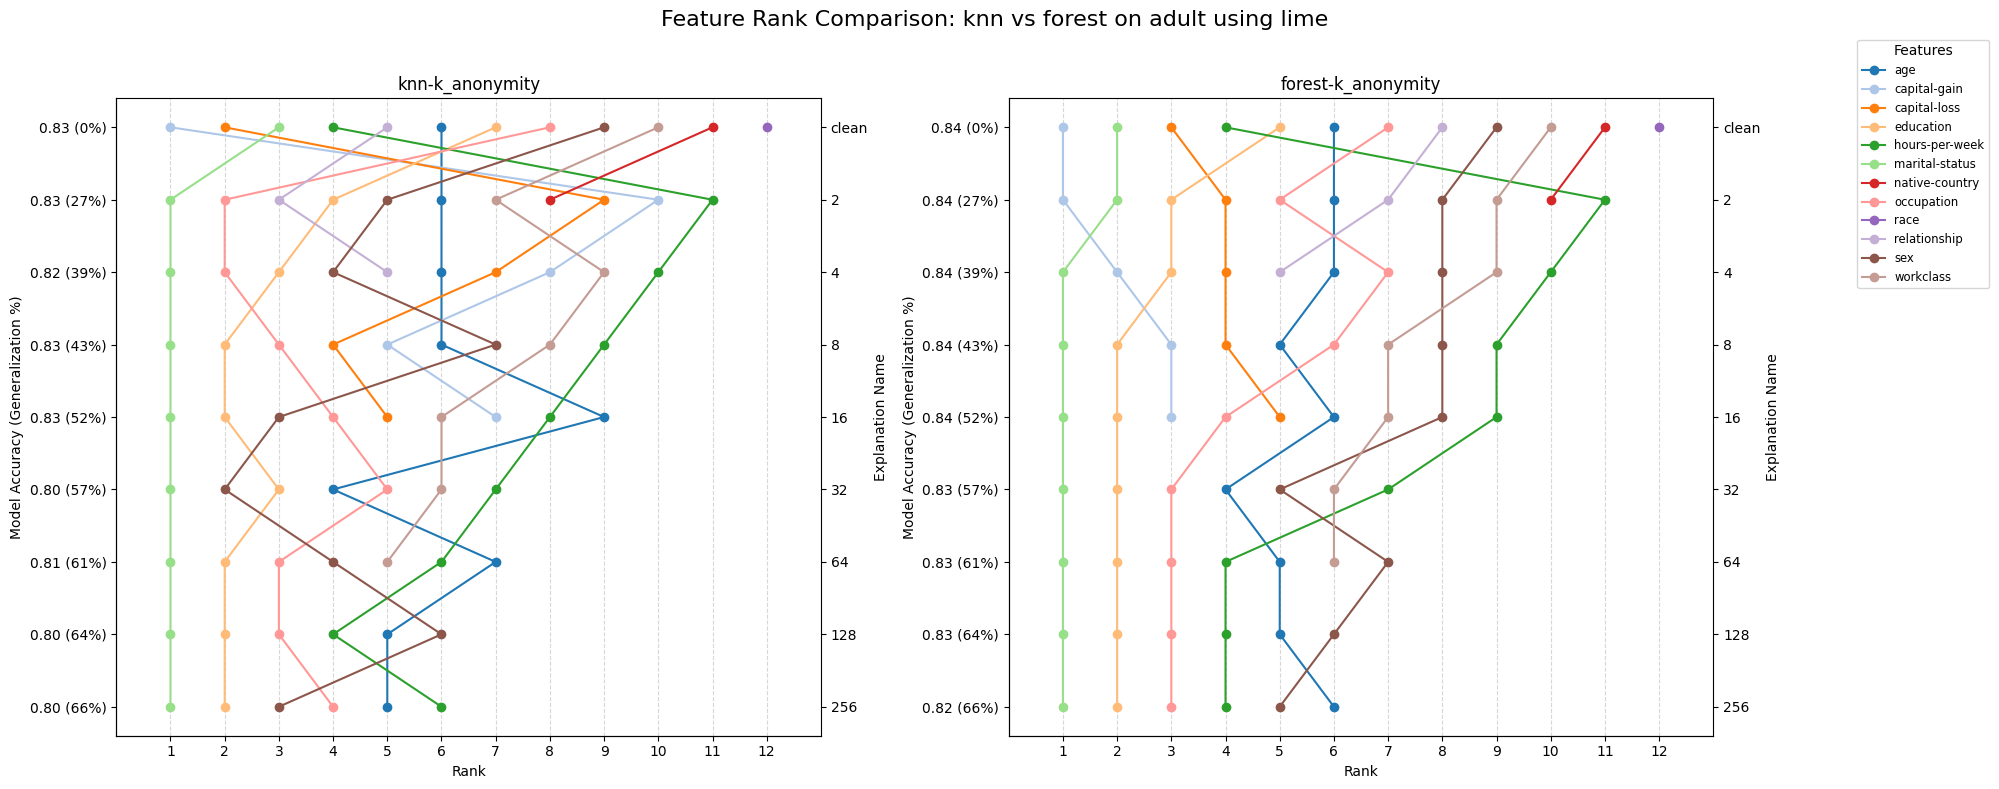

In [22]:
pl.plot_line_compare("knn","forest","adult","lime", "k_anonymity")

In [7]:
pl = plot_creator.PlotCreator(
    [
#        "forest",
        "MLP",
        #"knn"
    ],
    ["adult","adult_old"],
    "../data/",
)

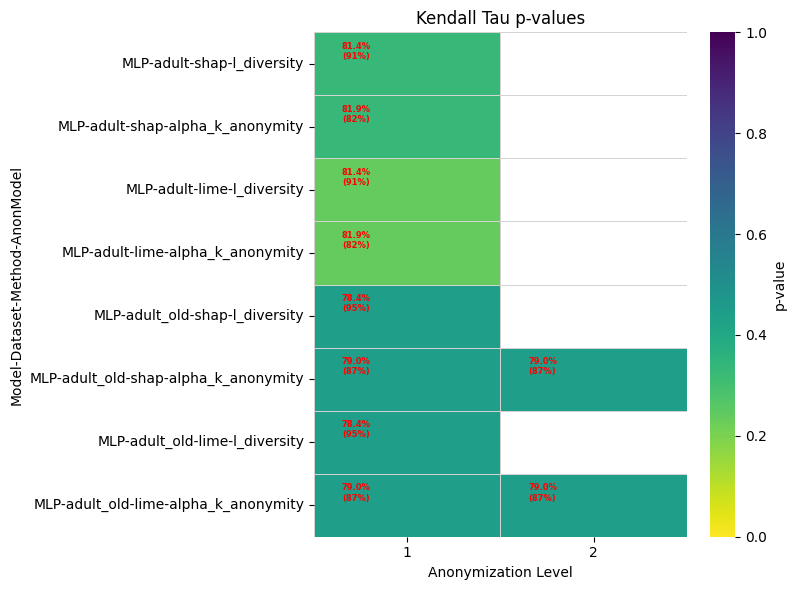

In [11]:
pl.plot_heatmap(classifiers=["MLP"], datasets=["adult", "adult_old"], methods=['l_diversity', 'alpha_k_anonymity'])

It is a binary target class so l-diversity can only be 2. A bit sad that alpha-k-anonymity could not be anonymized to more levels  
Again, we see choice of hiearchy has an effect. On accuracy, explainability and model cireteria.

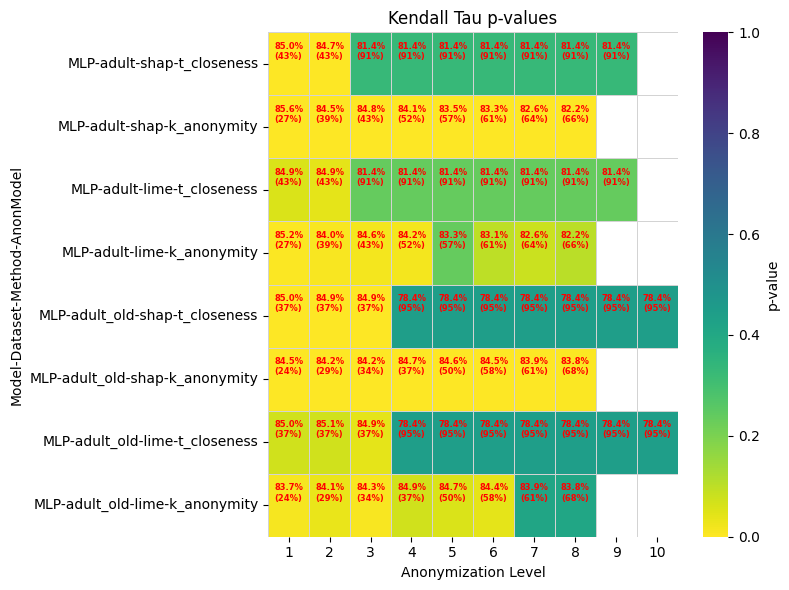

In [13]:
pl.plot_heatmap(classifiers=["MLP"], datasets=["adult", "adult_old"], methods=['k_anonymity', 't_closeness'])

Note, here MLP is actually very stable! This is also the biggest dataset, so it has had more points to be trained on. Maybe, the dataset is spaced out differently in the sapce and in the adult dataset it is just better at describing the points. 